# Purpose:
- To develop noise-robust online motion estimation algorithm
- I want to see if I modifying peak estimation from correlation values improve the performance.
- To do that, I need to reproduce ScanImage online motion estimation (MariusMotionEstimator)
    - First, check if the results match with the logged data.
    - If they match, modify the peak estimation algorithm and check if the performance would be improved.


In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py
import tifffile
import pandas as pd
from register_to_volume import MariusMotionEstimator as MME

%load_ext autoreload
%autoreload 2

%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
FOV_ORDER_DICT = {
    0: '0_reg_ch_1',
    1: '0_reg_ch_2',
    2: '1_reg_ch_1',
    3: '1_reg_ch_2',
    4: '2_reg_ch_1',
    5: '2_reg_ch_2',
    6: '3_reg_ch_1',
    7: '3_reg_ch_2',
}

PLANE_IND_DICT = {0: (3, 2),
                  1: (2, 2),
                  2: (1, 2),
                  3: (0, 2),
                  4: (0, 1),
                  5: (1, 1),
                  6: (2, 1),
                  7: (3, 1)}

PLANE_ORDER = [7, 5, 3, 1, 0, 2, 4, 6]
PLANE_DEPTHS = range(40, 330, 40)

def reformat_df(df):
    # strip blank spaces from column names
    df.columns = df.columns.str.strip()
    for col in df.columns:
        if isinstance(df[col].values[0], str):
            df[col] = df[col].str.strip()
    df['roiName'] = df['roiName'].str.strip()
    # convert str of list to a list
    def _str_to_float_list(x):
        """
        Convert a string representation of a list to a list of floats.
        """
        return [float(np.round(float(s), 4)) for s in x.split('[')[1].split(']')[0].split(' ')]
    list_columns = ['drPixel', 'drRef', 'confidence']
    for col in list_columns:
        df[col] = df[col].apply(lambda x: _str_to_float_list(x))

    assert len(df) % 2 == 0, f'Number of motion estimates ({len(df)}) is not even'
    channels = ((df.index.values % 2) + 1).astype(int)
    df['channel'] = channels
    zs = np.sort(df.z.unique())
    df['pair_ind'] = df['z'].apply(lambda x: np.where(zs == x)[0][0])
    
    def _get_plane_ind(row):
        for key, value in PLANE_IND_DICT.items():
            if value == (row['pair_ind'], row['channel']):
                return key
        return None

    df['plane_ind'] = df.apply(_get_plane_ind, axis=1)
    
    return df

In [ ]:
mme = MME()

In [31]:
motion_estimation_log_path = Path(r"\\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250425_783551\1433348723_timeseries_Motion_00002.csv")
motion_estimation_log = pd.read_csv(motion_estimation_log_path)
motion_estimation_log = reformat_df(motion_estimation_log)


In [32]:
motion_estimation_log

,timestamp,frameNumber,roiName,z,drPixel,drRef,confidence,userData,channel,pair_ind,plane_ind
0,0.000000,1,ROI 1,-176.0,"[-0.6364, -4.1818, -2.3182]","[-0.0032, -0.0208, -2.3182]","[0.0568, 0.0568, 0.0568]",,1,0,4
1,0.000000,1,ROI 1,-176.0,"[-1.0909, -4.0909, -0.8864]","[-0.0054, -0.0204, -0.8864]","[0.0216, 0.0216, 0.0216]",,2,0,3
2,0.535124,24,ROI 1,-60.0,"[-1.2727, -8.1818, -1.5682]","[-0.0063, -0.0407, -1.5682]","[0.014, 0.014, 0.014]",,1,3,7
3,0.535124,24,ROI 1,-60.0,"[-2.4545, -5.6364, -0.8182]","[-0.0122, -0.028, -0.8182]","[0.0309, 0.0309, 0.0309]",,2,3,0
4,0.674722,30,ROI 1,-136.0,"[-0.3636, -3.6364, -1.5]","[-0.0018, -0.0181, -1.5]","[0.0347, 0.0347, 0.0347]",,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...
13621,940.303795,40406,ROI 1,-136.0,"[-3.0, -6.3636, -0.6818]","[-0.0149, -0.0317, -0.6818]","[0.0311, 0.0311, 0.0311]",,2,1,2
13622,940.327068,40407,ROI 1,-100.0,"[-3.5455, -9.4545, -0.0682]","[-0.0176, -0.047, -0.0682]","[0.0296, 0.0296, 0.0296]",,1,2,6
13623,940.327068,40407,ROI 1,-100.0,"[-2.0909, -6.9091, -0.2045]","[-0.0104, -0.0344, -0.2045]","[0.0365, 0.0365, 0.0365]",,2,2,1
13624,940.350340,40408,ROI 1,-60.0,"[-3.1818, -7.8182, 6.0682]","[-0.0158, -0.0389, 6.0682]","[0.0129, 0.0129, 0.0129]",,1,3,7


In [36]:
estimated_motion = pd.DataFrame(motion_estimation_log.groupby('plane_ind')['drPixel'].apply(lambda x: [v[2] for v in x.values]))
estimated_motion.rename(columns={'drPixel': 'z'}, inplace=True)
estimated_motion.head()


,z
plane_ind,
0,"[-0.8182, -1.3636, -2.1136, -1.8409, -1.1591, ..."
1,"[-0.5455, -1.4318, -0.5455, -0.8864, -0.2727, ..."
2,"[-1.1591, 0.4773, 0.0, 0.4773, -0.5455, -0.409..."
3,"[-0.8864, -1.5682, 0.0, -1.7727, -0.8864, -2.2..."
4,"[-2.3182, -2.1136, -2.25, -2.3182, -1.5682, -1..."


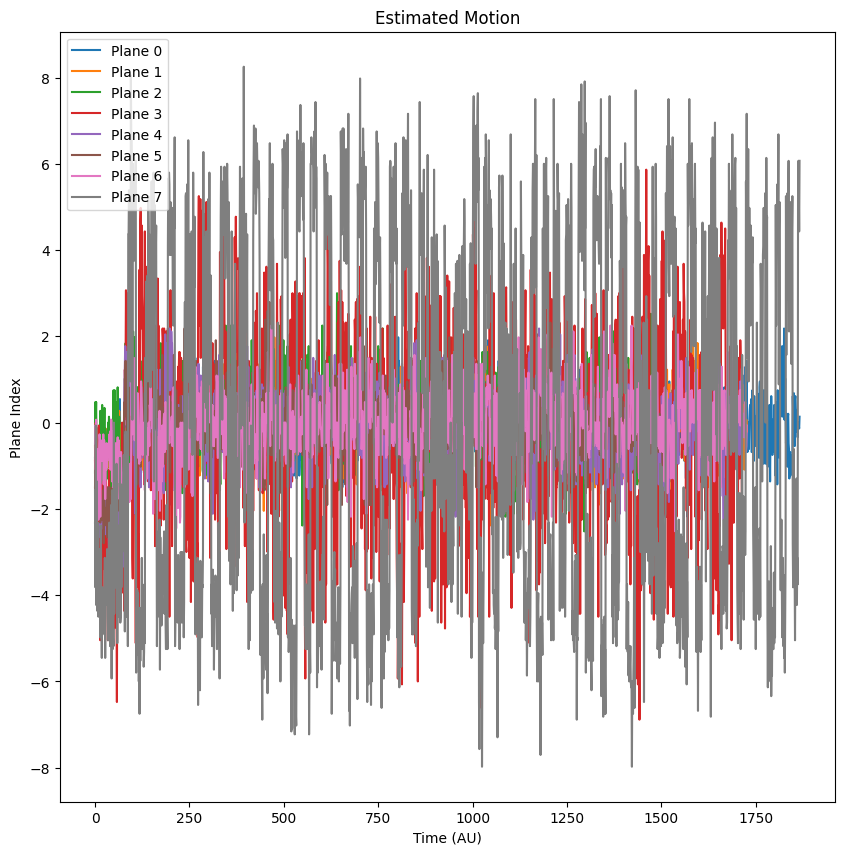

In [44]:
fig, ax = plt.subplots(figsize=(10, 10))
for i, row in estimated_motion.iterrows():
    ax.plot(row['z'], label=f'Plane {i}')
ax.set_title('Estimated Motion')
ax.set_ylabel('Plane Index')
ax.set_xlabel('Time (AU)')
ax.legend()



In [46]:
estimation_confidence = pd.DataFrame(motion_estimation_log.groupby('plane_ind')['confidence'].apply(lambda x: [v[2] for v in x.values]))
estimation_confidence.head()


,confidence
plane_ind,
0,"[0.0309, 0.0331, 0.0296, 0.0319, 0.033, 0.0302..."
1,"[0.0354, 0.0329, 0.0342, 0.033, 0.0352, 0.0356..."
2,"[0.0269, 0.0262, 0.0295, 0.0276, 0.0299, 0.027..."
3,"[0.0216, 0.0226, 0.019, 0.0204, 0.0171, 0.0196..."
4,"[0.0568, 0.0493, 0.0452, 0.0491, 0.0432, 0.046..."


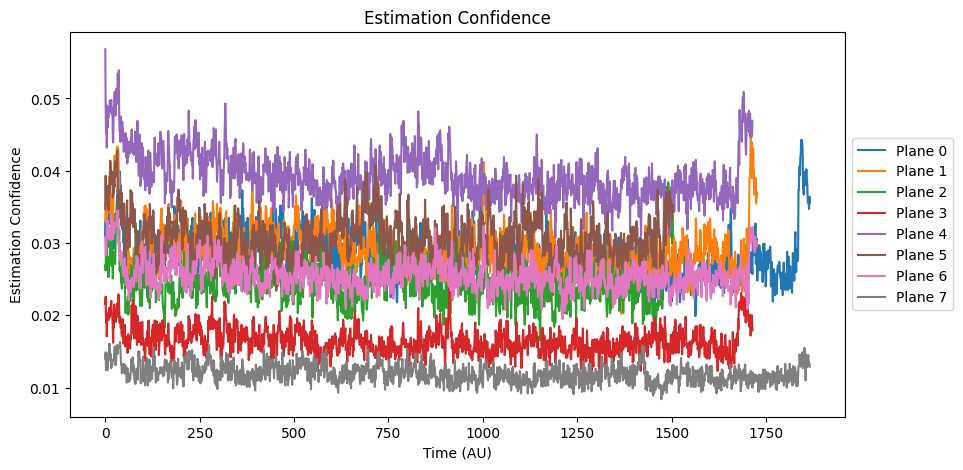

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, row in estimation_confidence.iterrows():
    ax.plot(row['confidence'], label=f'Plane {i}')
ax.set_title('Estimation Confidence')
ax.set_xlabel('Time (AU)')
ax.set_ylabel('Estimation Confidence')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))




In [50]:
plane_ind = 0
zstack_name_base = FOV_ORDER_DICT[plane_ind]
zstack_dir = Path(r"\\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250425_783551\sorted_local_z_stacks")
zstack_path = next(zstack_dir.glob(f"*{zstack_name_base}*.tif*"))
zstack = tifffile.imread(zstack_path)


In [64]:
ref_data = {
    'image_data': [np.transpose(zstack, (1,2,0))],
    'channels': [1],
    'zs': np.arange(zstack.shape[0])*0.75 - 30,
}

mme = MME(ref_data)

(512, 1, 'even')
fhg shape: (512, 512)
cf_ref_img shape: (512, 512, 81)
fhg_expanded shape: (512, 512, 81)


In [ ]:
plane_log = motion_estimation_log.query('plane_ind == @plane_ind').copy()
plane_log['frame_idx'] = (plane_log['frameNumber']-1) // 8
plane_log


,timestamp,frameNumber,roiName,z,drPixel,drRef,confidence,userData,channel,pair_ind,plane_ind,frame_idx
3,0.535124,24,ROI 1,-60.0,"[-2.4545, -5.6364, -0.8182]","[-0.0122, -0.028, -0.8182]","[0.0309, 0.0309, 0.0309]",,2,3,0,2
15,1.558844,68,ROI 1,-60.0,"[-1.8182, -3.7273, -1.3636]","[-0.009, -0.0185, -1.3636]","[0.0331, 0.0331, 0.0331]",,2,3,0,8
21,2.024173,88,ROI 1,-60.0,"[-2.2727, -3.3636, -2.1136]","[-0.0113, -0.0167, -2.1136]","[0.0296, 0.0296, 0.0296]",,2,3,0,10
25,2.303370,100,ROI 1,-60.0,"[-2.4545, -3.3636, -1.8409]","[-0.0122, -0.0167, -1.8409]","[0.0319, 0.0319, 0.0319]",,2,3,0,12
33,3.513230,152,ROI 1,-60.0,"[-2.0, -3.6364, -1.1591]","[-0.01, -0.0181, -1.1591]","[0.033, 0.033, 0.033]",,2,3,0,18
...,...,...,...,...,...,...,...,...,...,...,...,...
13597,938.581626,40332,ROI 1,-60.0,"[-0.4545, -5.8182, 0.0]","[-0.0023, -0.029, 0.0]","[0.0359, 0.0359, 0.0359]",,2,3,0,5041
13601,938.860897,40344,ROI 1,-60.0,"[-0.7273, -5.7273, 0.0]","[-0.0036, -0.0285, 0.0]","[0.0355, 0.0355, 0.0355]",,2,3,0,5042
13603,939.047077,40352,ROI 1,-60.0,"[-0.7273, -5.9091, -0.0682]","[-0.0036, -0.0294, -0.0682]","[0.0347, 0.0347, 0.0347]",,2,3,0,5043
13611,939.698709,40380,ROI 1,-60.0,"[-1.0909, -6.0, -0.1364]","[-0.0054, -0.0299, -0.1364]","[0.0364, 0.0364, 0.0364]",,2,3,0,5047


In [ ]:
frame_indices = plane_log['frame_idx'].unique()
frame_ind = frame_indices[0]

plane_path = Path(r"\\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250425_783551\1433348723_timeseries_00002_00.h5")
with h5py.File(plane_path, 'r') as f:
    frame = f['data'][frame_ind]

dr, confidence, correlation, correlation_3d = mme.estimate_motion(frame)


In [146]:
from tqdm import tqdm
session_df = pd.DataFrame()
for plane_ind in tqdm(range(8)):
    zstack_name_base = FOV_ORDER_DICT[plane_ind]
    zstack_dir = Path(r"\\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250425_783551\sorted_local_z_stacks")
    zstack_path = next(zstack_dir.glob(f"*{zstack_name_base}*.tif*"))
    zstack = tifffile.imread(zstack_path)

    ref_zstack = np.transpose(zstack, (1,2,0))
    zs = np.arange(zstack.shape[0])*0.75 - 30

    mme = MME(ref_zstack, zs)

    plane_log = motion_estimation_log.query('plane_ind == @plane_ind').copy()
    plane_log['frame_idx'] = (plane_log['frameNumber']-1) // 8

    frame_indices = plane_log['frame_idx'].unique()
    plane_path = Path(f"\\\\allen\\programs\\mindscope\\workgroups\\learning\\pilots\\online_motion_correction\\250425_783551\\1433348723_timeseries_00002_{plane_ind:02d}.h5")
    dr_list = []
    confidence_list = []
    z_correlation_list = []
    with h5py.File(plane_path, 'r') as f:
        for frame_ind in tqdm(frame_indices):
            frame = f['data'][frame_ind]
            dr, confidence, correlation = mme.estimate_motion(frame)
            dr_list.append(dr)
            confidence_list.append(confidence)
            z_correlation_list.append(correlation[2])
    plane_df = pd.DataFrame({'dr': dr_list, 'confidence': confidence_list, 'z_correlation': z_correlation_list})
    plane_df['frame_idx'] = frame_indices
    plane_df['plane_ind'] = plane_ind
    session_df = pd.concat([session_df, plane_df])

# save
save_fn = r"\\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250425_783551\1433348723_timeseries_Motion_00002_posthoc_motion_estimation.csv"
session_df.to_csv(save_fn, index=False)



100%|██████████| 8/8 [57:41<00:00, 432.64s/it]
